In [ ]:
import pandas as pd
import numpy as np

features = pd.read_csv("merged_output.csv")
ev = pd.read_csv("ev2025.csv")

features.head()

,region_country,year,code,Greenhouse gas emissions per capita,population,electricity_generation,Urban_pct
0,Africa,2000,AFR,15.413796,47243054,210.860004,99.656419
1,Africa,2001,AFR,15.306290,47651426,210.289996,100.218733
2,Africa,2002,AFR,14.794578,48105292,220.810002,100.767205
3,Africa,2003,AFR,15.477100,48587407,234.470006,101.377367
4,Africa,2004,AFR,16.693630,49079595,244.840001,102.021515


In [ ]:
ev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,agg_group,is_projection
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,World,True
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,World,True
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Country,True
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Country,True
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,World,True


In [ ]:
# Generate target: EV sales
ev_sales = (
    ev[
        (ev["category"] == "Historical") &
        (ev["parameter"] == "EV sales") &
        (ev["mode"] == "Cars") &
        (ev["powertrain"].isin(["BEV", "PHEV"])) &
        (ev["year"].between(2010, 2024))
    ]
    .groupby(["region_country", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "ev_sales"})
)

ev_sales.head()

,region_country,year,ev_sales
0,Africa,2013,34.0
1,Africa,2014,15.0
2,Africa,2015,240.0
3,Africa,2016,380.0
4,Africa,2017,202.0


In [ ]:
# Merge target with features
df = features.merge(ev_sales, on=["region_country", "year"], how="inner")

df["ev_sales_log"] = np.log1p(df["ev_sales"])
df["population_log"] = np.log1p(df["population"])
df["electricity_generation_log"] = np.log1p(df["electricity_generation"])
df["electricity_per_capita"] = df["electricity_generation"] / df["population"]

df = df.sort_values(["region_country", "year"])
df.head()

,region_country,year,code,Greenhouse gas emissions per capita,population,electricity_generation,Urban_pct,ev_sales,ev_sales_log,population_log,electricity_generation_log,electricity_per_capita
0,Africa,2013,AFR,15.174379,54780897,256.389997,105.867472,34.0,3.555348,17.818852,5.550592,0.000005
1,Africa,2014,AFR,15.808058,55699503,255.220004,106.073858,15.0,2.772589,17.835482,5.546036,0.000005
2,Africa,2015,AFR,15.410494,56830783,250.510003,106.304439,240.0,5.484797,17.855589,5.527483,0.000004
3,Africa,2016,AFR,15.702925,57369386,253.309998,106.556661,380.0,5.942799,17.865021,5.538554,0.000004
4,Africa,2017,AFR,15.465017,57747601,255.649999,106.827972,202.0,5.313206,17.871592,5.547713,0.000004


In [ ]:
df["region_country"].unique()

array(['Africa', 'Asia Pacific', 'Australia', 'Austria', 'Belgium',
       'Brazil', 'Bulgaria', 'Canada', 'Central and South America',
       'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus',
       'Czech Republic', 'Denmark', 'Estonia', 'Europe', 'Finland',
       'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea',
       'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Mexico',
       'Middle East and Caspian', 'Netherlands', 'New Zealand',
       'North America', 'Norway', 'Poland', 'Portugal', 'Romania',
       'Russia', 'Seychelles', 'Slovakia', 'Slovenia', 'South Africa',
       'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Turkiye', 'USA',
       'United Kingdom', 'Uzbekistan', 'Viet Nam', 'World'], dtype=object)

In [ ]:
country_ev_sales = ev[
    (ev["category"] == "Historical") &
    (ev["agg_group"] == "Country") &
    (ev["parameter"] == "EV sales") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"].isin(["BEV", "PHEV"])) &
    (ev["year"].between(2016, 2024))
].groupby(["region_country", "year"], as_index=False)["value"].sum()

country_ev_sales = country_ev_sales.rename(columns={"value": "ev_sales"})

top_countries = (
    country_ev_sales
    .sort_values(["year", "ev_sales"], ascending=[True, False])
    .groupby("year")
    .head(5)
)

top_countries

,region_country,year,ev_sales
63,China,2016,339000.0
439,USA,2016,160000.0
305,Norway,2016,45000.0
287,Netherlands,2016,43000.0
448,United Kingdom,2016,39000.0
64,China,2017,580000.0
440,USA,2017,194000.0
306,Norway,2017,62000.0
148,Germany,2017,54000.0
228,Japan,2017,54000.0


This output confirms that China ranked first among countries in EV car sales every year from 2016 to 2024. The gap between China and the second-ranked country is large, especially after 2021, suggesting that China’s EV adoption scale is structurally different from other markets.

In [ ]:
# Run model on country only, filter region out
region_names = [
    "World", "Africa", "Asia Pacific", "Europe", "EU27",
    "Central and South America", "Middle East and Caspian", "North America"
]

country_df = df[~df["region_country"].isin(region_names)].copy()

In [ ]:
# First, try linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model_df = country_df.dropna(subset=[
    "ev_sales_log",
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita",
    "electricity_per_capita"
])

features_cols = [
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita",
    "electricity_per_capita"
]

train = model_df[model_df["year"] <= 2021]
test = model_df[model_df["year"] >= 2022]

X_train = train[features_cols]
y_train = train["ev_sales_log"]

X_test = test[features_cols]
y_test = test["ev_sales_log"]

reg = LinearRegression()
reg.fit(X_train, y_train)

pred = reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

pd.DataFrame({
    "feature": features_cols,
    "coefficient": reg.coef_
}).sort_values("coefficient", ascending=False)

MAE: 3.1771401630672167
R2: -1.8315642927400142


,feature,coefficient
2,electricity_generation_log,2.946366
0,Urban_pct,0.023909
3,Greenhouse gas emissions per capita,-0.129248
1,population_log,-2.153585
4,electricity_per_capita,-66151.778228


The linear regression coefficient for Urban_pct is positive, suggesting that higher urbanization is associated with higher EV sales. However, the negative test R2 indicates weak out-of-sample predictive performance. Therefore, this model should be interpreted as exploratory regression rather than a reliable forecasting model.

In [ ]:
import statsmodels.api as sm

model_df = country_df.dropna(subset=[
    "ev_sales_log",
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita"
])

X = model_df[
    [
        "Urban_pct",
        "population_log",
        "electricity_generation_log",
        "Greenhouse gas emissions per capita"
    ]
]

X = sm.add_constant(X)
y = model_df["ev_sales_log"]

ols = sm.OLS(y, X).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:           ev_sales_log   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     63.05
Date:                Sat, 30 May 2026   Prob (F-statistic):           5.34e-45
Time:                        13:46:33   Log-Likelihood:                -1522.6
No. Observations:                 651   AIC:                             3055.
Df Residuals:                     646   BIC:                             3078.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

The OLS result shows that Urban_pct has a positive and statistically significant association with EV sales log. A one-point increase in urbanization rate is associated with an increase in log EV sales, holding other variables constant. Electricity generation also has a strong positive relationship with EV sales. However, the R-squared is moderate at 0.281, so these variables explain part, but not all, of the variation in EV sales.

The Durbin-Watson statistic is low and the condition number is high, suggesting possible autocorrelation and multicollinearity. The results are useful for interpretation, but not strong causal proof.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def run_granger_log(country, x_col="Urban_pct", y_col="ev_sales_log", maxlag=2):
    temp = (
        country_df[country_df["region_country"] == country]
        .sort_values("year")[[y_col, x_col]]
        .dropna()
    )

    print(country, temp.shape)

    if len(temp) < maxlag + 5:
        print("Not enough observations")
        return

    return grangercausalitytests(temp[[y_col, x_col]], maxlag=maxlag, verbose=True)

run_granger_log("China", maxlag=2)

China (15, 2)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1
ssr based chi2 test:   chi2=1.2990  , p=0.2544  , df=1
likelihood ratio test: chi2=1.2422  , p=0.2650  , df=1
parameter F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2083  , p=0.3479  , df_denom=8, df_num=2
ssr based chi2 test:   chi2=3.9269  , p=0.1404  , df=2
likelihood ratio test: chi2=3.4314  , p=0.1798  , df=2
parameter F test:         F=1.2083  , p=0.3479  , df_denom=8, df_num=2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(1.020636936238793),
    np.float64(0.33407451938496135),
    np.float64(11.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.2989924643039186),
    np.float64(0.2543973436155853),
    np.int64(1)),
   'lrtest': (np.float64(1.2422150245191759),
    np.float64(0.26504459124271995),
    np.int64(1)),
   'params_ftest': (np.float64(1.0206369362388632),
    np.float64(0.3340745193849455),
    np.float64(11.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.208266289105013),
    np.float64(0.3479102645182693),
    np.float64(8.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(3.9268654395912925),
    np.float64(0.14037572238956042),
    np.int64(2)),
   'lrtest': (np.float64(3.431384752377088),
    np.float64(0.1798391612440698),
    np.int64(2)),
   'params_ftest': (np.float64(1.2082662891049942),
    np.float64(0.3479102645182741),
    np.float64(8.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
          [0

The Granger causality test does not find statistically significant evidence that past urbanization predicts future EV sales in China. Both lag 1 and lag 2 p-values are above 0.05, so we fail to reject the null hypothesis of no Granger causality. This does not contradict the regression result; it only means urbanization is associated with EV sales cross-sectionally, but does not significantly improve time-series prediction for China within this short 15-year sample. It's rather a positive association than a causation of increasing EV sales.

In [ ]:
import pandas as pd
import numpy as np

# Keep country-level observations only
region_names = [
    "World", "Africa", "Asia Pacific", "Europe", "EU27",
    "Central and South America", "Middle East and Caspian", "North America"
]

country_df = df[~df["region_country"].isin(region_names)].copy()

# Add EV sales share
ev_sales_share = (
    ev[
        (ev["category"] == "Historical") &
        (ev["agg_group"] == "Country") &
        (ev["parameter"] == "EV sales share") &
        (ev["mode"] == "Cars") &
        (ev["year"].between(2010, 2024))
    ]
    .groupby(["region_country", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "ev_sales_share"})
)

country_df = country_df.merge(
    ev_sales_share,
    on=["region_country", "year"],
    how="left"
)

country_df["ev_sales_log"] = np.log1p(country_df["ev_sales"])
country_df["population_log"] = np.log1p(country_df["population"])
country_df["electricity_generation_log"] = np.log1p(country_df["electricity_generation"])

final_features = [
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita",
    "year"
]

model_df = country_df.dropna(subset=final_features + ["ev_sales_log"]).copy()

model_df.head()

,region_country,year,code,Greenhouse gas emissions per capita,population,electricity_generation,Urban_pct,ev_sales,ev_sales_log,population_log,electricity_generation_log,electricity_per_capita,ev_sales_share
0,Australia,2011,AUS,38.641823,22479779,256.279999,86.326895,49.0,3.912023,16.928127,5.550165,0.000011,0.0061
1,Australia,2012,AUS,34.843830,22852648,250.660004,86.445126,250.0,5.525453,16.944578,5.528079,0.000011,0.0290
2,Australia,2013,AUS,29.860008,23236271,249.559998,86.574052,290.0,5.673323,16.961225,5.523698,0.000011,0.0330
3,Australia,2014,AUS,28.444250,23595599,247.649994,86.722129,1320.0,7.186144,16.976571,5.516046,0.000010,0.1500
4,Australia,2015,AUS,26.639627,23947997,253.990005,86.877864,1760.0,7.473637,16.991395,5.541224,0.000011,0.1900


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train = model_df[model_df["year"] <= 2021]
test = model_df[model_df["year"] >= 2022]

X_train = train[final_features]
y_train = train["ev_sales_log"]

X_test = test[final_features]
y_test = test["ev_sales_log"]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=10000)),
    "Random Forest": RandomForestRegressor(
        n_estimators=80,
        random_state=42,
        min_samples_leaf=3
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=80,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "model": name,
        "MAE_log": mean_absolute_error(y_test, pred),
        "RMSE_log": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

model_results = (
    pd.DataFrame(results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

model_results

,model,MAE_log,RMSE_log,R2
0,Lasso,1.105286,1.458786,0.490052
1,Ridge,1.112176,1.467911,0.483652
2,Linear Regression,1.125301,1.485123,0.471472
3,Random Forest,1.268199,1.516894,0.448617
4,Gradient Boosting,1.298343,1.596008,0.389602


/tmp/ipykernel_987/1515727601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


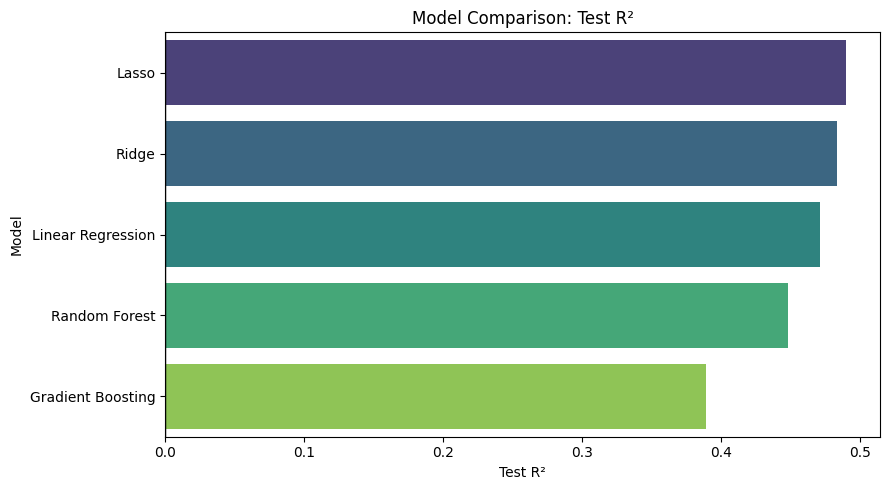

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="R2",
    y="model",
    palette="viridis"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Model Comparison: Test R²")
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

X = model_df[final_features]
X = sm.add_constant(X)

y = model_df["ev_sales_log"]

ols_final = sm.OLS(y, X).fit()

print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:           ev_sales_log   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     294.7
Date:                Sat, 30 May 2026   Prob (F-statistic):          7.11e-164
Time:                        13:46:34   Log-Likelihood:                -1242.8
No. Observations:                 651   AIC:                             2498.
Df Residuals:                     645   BIC:                             2525.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [ ]:
ols_table = pd.DataFrame({
    "feature": ols_final.params.index,
    "coef": ols_final.params.values,
    "p_value": ols_final.pvalues.values,
    "ci_low": ols_final.conf_int()[0].values,
    "ci_high": ols_final.conf_int()[1].values
})

ols_table["significant_0.05"] = ols_table["p_value"] < 0.05

ols_table

,feature,coef,p_value,ci_low,ci_high,significant_0.05
0,const,-957.491865,4.989552e-119,-1022.313747,-892.669984,True
1,Urban_pct,0.026517,7.873655e-07,0.016077,0.036957,True
2,population_log,-1.279105,1.630804e-28,-1.495081,-1.063129,True
3,electricity_generation_log,2.200961,2.459388e-59,1.961711,2.440211,True
4,Greenhouse gas emissions per capita,-0.081771,1.219934e-07,-0.111781,-0.051761,True
5,year,0.483246,1.678441e-122,0.451232,0.515261,True


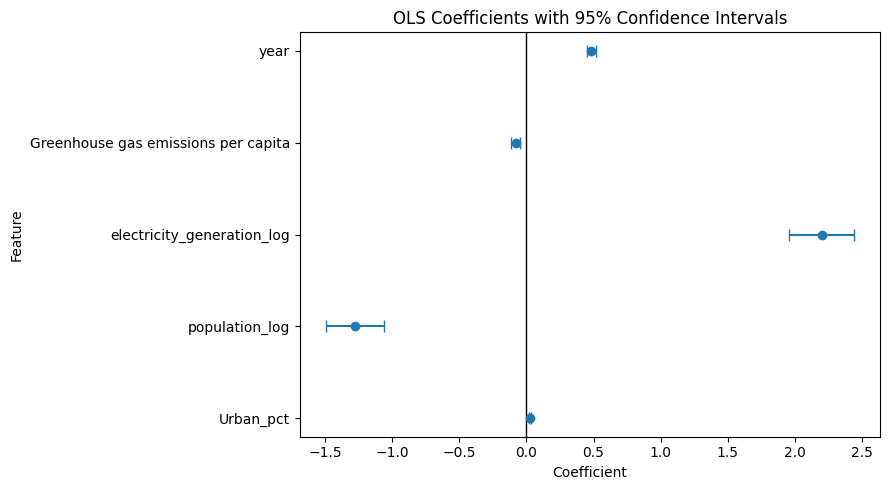

In [ ]:
plot_table = ols_table[ols_table["feature"] != "const"].copy()

plt.figure(figsize=(9, 5))

plt.errorbar(
    plot_table["coef"],
    plot_table["feature"],
    xerr=[
        plot_table["coef"] - plot_table["ci_low"],
        plot_table["ci_high"] - plot_table["coef"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(0, color="black", linewidth=1)
plt.title("OLS Coefficients with 95% Confidence Intervals")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

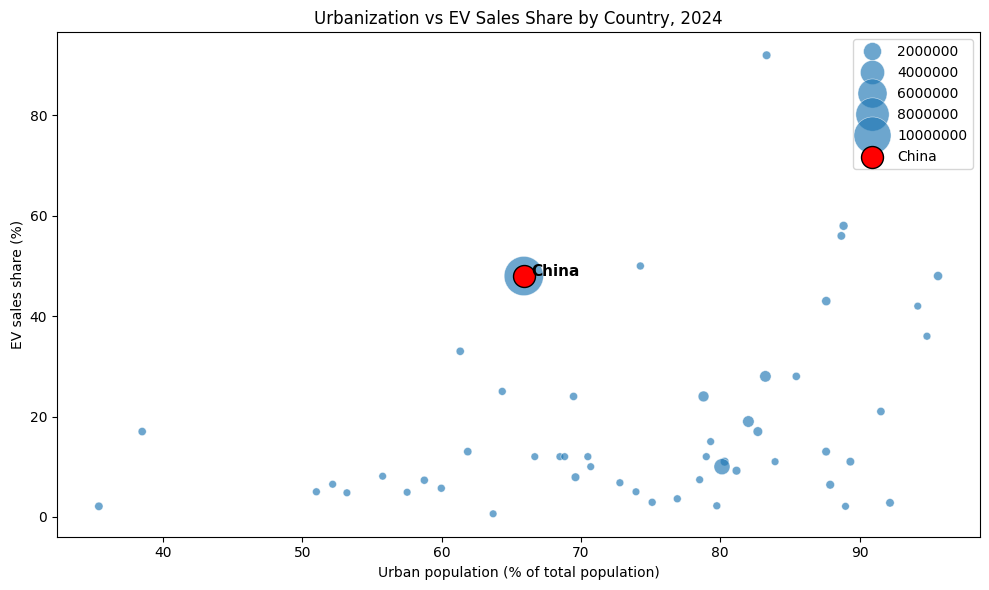

In [ ]:
scatter_df = country_df[
    (country_df["year"] == 2024)
].dropna(subset=["Urban_pct", "ev_sales_share", "ev_sales"])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_df,
    x="Urban_pct",
    y="ev_sales_share",
    size="ev_sales",
    sizes=(30, 800),
    alpha=0.65,
    legend=True
)

china_2024 = scatter_df[scatter_df["region_country"] == "China"]

plt.scatter(
    china_2024["Urban_pct"],
    china_2024["ev_sales_share"],
    color="red",
    s=250,
    edgecolor="black",
    label="China"
)

for _, row in china_2024.iterrows():
    plt.text(
        row["Urban_pct"] + 0.5,
        row["ev_sales_share"],
        "China",
        fontsize=11,
        weight="bold"
    )

plt.title("Urbanization vs EV Sales Share by Country, 2024")
plt.xlabel("Urban population (% of total population)")
plt.ylabel("EV sales share (%)")
plt.legend()
plt.tight_layout()
plt.show()

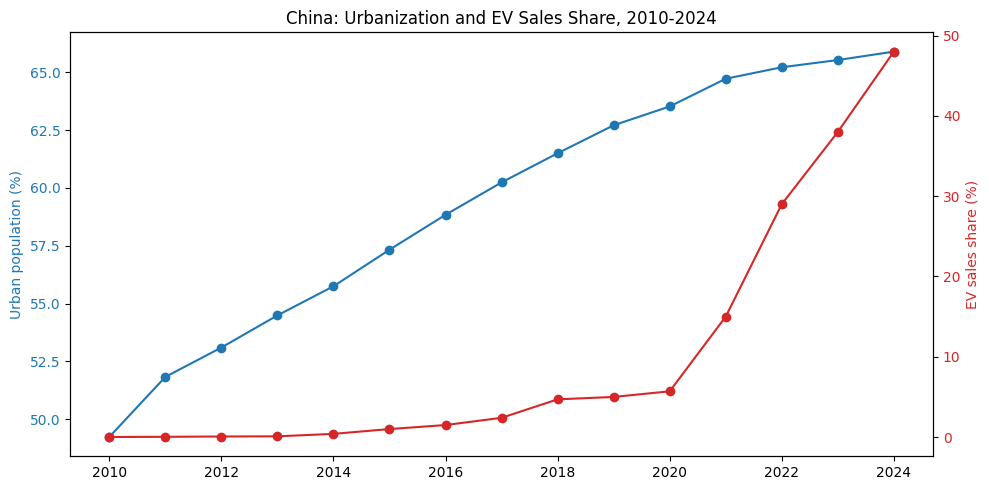

In [ ]:
china = country_df[country_df["region_country"] == "China"].sort_values("year")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    china["year"],
    china["Urban_pct"],
    marker="o",
    color="tab:blue",
    label="Urban_pct"
)

ax1.set_ylabel("Urban population (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

ax2.plot(
    china["year"],
    china["ev_sales_share"],
    marker="o",
    color="tab:red",
    label="EV sales share"
)

ax2.set_ylabel("EV sales share (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("China: Urbanization and EV Sales Share, 2010-2024")
fig.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def run_granger_log(country, x_col="Urban_pct", y_col="ev_sales_log", maxlag=2):
    temp = (
        country_df[country_df["region_country"] == country]
        .sort_values("year")[[y_col, x_col]]
        .dropna()
    )

    print(country, temp.shape)

    if len(temp) < maxlag + 5:
        print("Not enough observations")
        return None

    return grangercausalitytests(
        temp[[y_col, x_col]],
        maxlag=maxlag,
        verbose=True
    )

granger_china = run_granger_log("China", maxlag=2)

China (15, 2)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1
ssr based chi2 test:   chi2=1.2990  , p=0.2544  , df=1
likelihood ratio test: chi2=1.2422  , p=0.2650  , df=1
parameter F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2083  , p=0.3479  , df_denom=8, df_num=2
ssr based chi2 test:   chi2=3.9269  , p=0.1404  , df=2
likelihood ratio test: chi2=3.4314  , p=0.1798  , df=2
parameter F test:         F=1.2083  , p=0.3479  , df_denom=8, df_num=2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
granger_summary = []

for lag, result in granger_china.items():
    tests = result[0]

    granger_summary.append({
        "lag": lag,
        "ssr_F_stat": tests["ssr_ftest"][0],
        "ssr_F_p_value": tests["ssr_ftest"][1],
        "chi2_stat": tests["ssr_chi2test"][0],
        "chi2_p_value": tests["ssr_chi2test"][1]
    })

granger_summary = pd.DataFrame(granger_summary)

granger_summary

,lag,ssr_F_stat,ssr_F_p_value,chi2_stat,chi2_p_value
0,1,1.020637,0.334075,1.298992,0.254397
1,2,1.208266,0.347910,3.926865,0.140376


In [ ]:
model_results.to_csv("model_comparison_results.csv", index=False)
ols_table.to_csv("ols_final_results.csv", index=False)
granger_summary.to_csv("granger_china_results.csv", index=False)
scatter_df.to_csv("scatter_urban_ev_share_2024.csv", index=False)
china.to_csv("china_trend_data.csv", index=False)

print("Exported:")
print("- model_comparison_results.csv")
print("- ols_final_results.csv")
print("- granger_china_results.csv")
print("- scatter_urban_ev_share_2024.csv")
print("- china_trend_data.csv")

Exported:
- model_comparison_results.csv
- ols_final_results.csv
- granger_china_results.csv
- scatter_urban_ev_share_2024.csv
- china_trend_data.csv
